# 04. Decision trees and gradient boosting, derived

Trees have no weights and no gradient on their own. They are built by a different kind of rule:
**pick the single split that most reduces the error, then recurse.** Boosting puts gradients back in,
by fitting each new tree to the gradient of the loss.

| symbol | code name | what it is |
|---|---|---|
| $R$ | `rows` | a region: the set of rows that reached a node |
| $R_L, R_R$ | `left_rows, right_rows` | the two regions after a split on feature $j$ at threshold $t$ |
| $\bar{y}_R$ | `np.mean(y[rows])` | the mean target in a region: a leaf's prediction |
| $G$ | `gini` | Gini impurity of a region (classification) |
| $F_m(x)$ | `prediction` | the boosted model after $m$ trees |
| $r_i$ | `residuals` | the residual $y_i - F_{m-1}(x_i)$: what the first $m-1$ trees have not explained |
| $h_m(x)$ | `tree_m` | the $m$-th small tree, fit to the residuals |
| $\eta$ | `learning_rate` | shrinkage: how much of each tree's prediction is added |

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DB = "C:/Users/palla/OneDrive/Documents/Coding Projects/cheatsheets_and_templates/ML_derivations/data/ml_derivations.sqlite"
con = sqlite3.connect(DB)
def q(sql):
    """Run SQL against the project database and return a DataFrame."""
    return pd.read_sql(sql, con)

SEED = 42
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#9a9a94"

## 1. A regression tree: choosing one split

A leaf predicts the mean of its rows. The error of a region is its within-region sum of squares:

$$\text{SSE}(R) = \sum_{i \in R}\left(y_i - \bar{y}_R\right)^2$$

A split on feature $j$ at threshold $t$ sends rows with $x_{ij} \le t$ left and the rest right.
Its quality is how much error it removes:

$$\text{gain}(j, t) = \text{SSE}(R) - \big[\text{SSE}(R_L) + \text{SSE}(R_R)\big]$$

The tree tries **every feature and every cutpoint between adjacent sorted values** and keeps the
split with the largest gain. This is greedy: it never looks ahead. Then it does the same thing
inside each child, until a stopping rule (depth, minimum rows per leaf) says stop.

For classification the same recipe uses **Gini impurity** instead of SSE. For a region with class
proportions $p_1, \ldots, p_K$:

$$G(R) = 1 - \sum_{k=1}^{K} p_k^2$$

$G = 0$ when a region is all one class, $0.5$ for a 50/50 binary split. The split gain is the
weighted drop: $G(R) - \frac{|R_L|}{|R|}G(R_L) - \frac{|R_R|}{|R|}G(R_R)$.

**What this cell does:** implements `best_split`, which scans every feature and cutpoint, and runs it
on a small housing sample to find the root split.

In [2]:
def sum_squared_error(values):
    """SSE(R) = sum (y_i - mean)^2 for the rows in a region."""
    return np.sum((values - values.mean()) ** 2) if len(values) else 0.0

def best_split(X, y, min_rows_per_leaf=5):
    """Scan every feature and every cutpoint; return (feature index, threshold, gain) of the best."""
    n_rows, n_features = X.shape
    error_before = sum_squared_error(y)
    best = (None, None, 0.0)
    for j in range(n_features):
        order = np.argsort(X[:, j])
        x_sorted, y_sorted = X[order, j], y[order]
        for cut in range(min_rows_per_leaf, n_rows - min_rows_per_leaf):
            if x_sorted[cut] == x_sorted[cut - 1]:
                continue                                       # no boundary between equal values
            threshold = (x_sorted[cut - 1] + x_sorted[cut]) / 2  # midpoint between neighbors
            gain = error_before - sum_squared_error(y_sorted[:cut]) - sum_squared_error(y_sorted[cut:])
            if gain > best[2]:
                best = (j, threshold, gain)
    return best

housing = q("SELECT * FROM housing ORDER BY random() LIMIT 2000")
feature_names = [c for c in housing.columns if c != "median_house_value"]
X = housing[feature_names].to_numpy()
y = housing["median_house_value"].to_numpy()

j, t, gain = best_split(X, y)
print(f"root split: {feature_names[j]} <= {t:.3f}   removes {gain:.1f} of {sum_squared_error(y):.1f} SSE")

root split: medinc <= 5.541   removes 826.0 of 2730.4 SSE


## 2. Growing the whole tree

A tree is just `best_split` applied recursively. Each node either holds a prediction (a leaf) or a
question plus two child nodes. The stopping rules are the regularization: `max_depth` and
`min_rows_per_leaf` are the only things standing between a tree and memorizing every row.

**What this cell does:** builds a tiny tree class with `fit` and `predict`, then checks it against
`DecisionTreeRegressor` at the same depth. The library finds the same splits, so predictions match.

In [3]:
class RegressionTree:
    """A decision tree for regression, grown by recursive best_split. Minimal on purpose."""

    def __init__(self, max_depth=3, min_rows_per_leaf=5):
        self.max_depth, self.min_rows_per_leaf = max_depth, min_rows_per_leaf

    def fit(self, X, y):
        self.root = self._grow(X, y, depth=0)
        return self

    def _grow(self, X, y, depth):
        # A leaf: predict the mean of the rows that reached here.
        if depth >= self.max_depth or len(y) < 2 * self.min_rows_per_leaf:
            return {"leaf": True, "value": y.mean()}
        j, t, gain = best_split(X, y, self.min_rows_per_leaf)
        if j is None or gain <= 0:
            return {"leaf": True, "value": y.mean()}
        goes_left = X[:, j] <= t
        return {"leaf": False, "feature": j, "threshold": t,
                "left": self._grow(X[goes_left], y[goes_left], depth + 1),
                "right": self._grow(X[~goes_left], y[~goes_left], depth + 1)}

    def _predict_one(self, x, node):
        while not node["leaf"]:
            node = node["left"] if x[node["feature"]] <= node["threshold"] else node["right"]
        return node["value"]

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

hand_tree = RegressionTree(max_depth=3, min_rows_per_leaf=5).fit(X_train, y_train)
library_tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=SEED).fit(X_train, y_train)

def rmse(y, y_hat): return np.sqrt(np.mean((y - y_hat) ** 2))
print(f"depth-3 tree test RMSE:  by hand {rmse(y_test, hand_tree.predict(X_test)):.4f}   sklearn {rmse(y_test, library_tree.predict(X_test)):.4f}")
print(f"root split by hand: {feature_names[hand_tree.root['feature']]} <= {hand_tree.root['threshold']:.3f}")
print(f"root split sklearn: {feature_names[library_tree.tree_.feature[0]]} <= {library_tree.tree_.threshold[0]:.3f}")

depth-3 tree test RMSE:  by hand 0.8213   sklearn 0.8213
root split by hand: medinc <= 5.032
root split sklearn: medinc <= 5.032


## 3. Gradient boosting: trees as gradient steps

One shallow tree is a crude model. Boosting builds a strong model by adding many shallow trees,
**each one fit to what the previous ones got wrong.**

Start with a constant, the mean: $F_0(x) = \bar{y}$. Then for $m = 1, 2, \ldots, M$:

1. Compute residuals: $r_i = y_i - F_{m-1}(x_i)$
2. Fit a small tree $h_m$ to predict $r_i$ from $x_i$
3. Update: $F_m(x) = F_{m-1}(x) + \eta\, h_m(x)$

**Why this is "gradient" boosting.** For squared-error loss $L = \frac{1}{2}\sum_i (y_i - F(x_i))^2$,
the derivative with respect to the prediction for row $i$ is

$$\frac{\partial L}{\partial F(x_i)} = -(y_i - F(x_i)) = -r_i$$

So the residual is exactly the **negative gradient of the loss with respect to the current
prediction.** Fitting a tree to the residuals and adding it is a gradient-descent step, taken in
"function space": instead of adjusting weights, we adjust the prediction itself, and the tree is
how we represent the adjustment. For other losses (log loss for classification) step 1 computes
that loss's negative gradient instead of $y - F$, and everything else is unchanged.

$\eta$ (shrinkage, `learning_rate`) scales each step down, so no single tree dominates. Small
$\eta$ with many trees generalizes better than large $\eta$ with few.

**What this cell does:** runs exactly those three steps with the hand-built tree, tracks test error as
trees are added, and compares to `GradientBoostingRegressor`.

hand-rolled boosting: 100 trees in 49s, test RMSE 0.5929


sklearn:              test RMSE 0.5981
one depth-3 tree:     test RMSE 0.8213


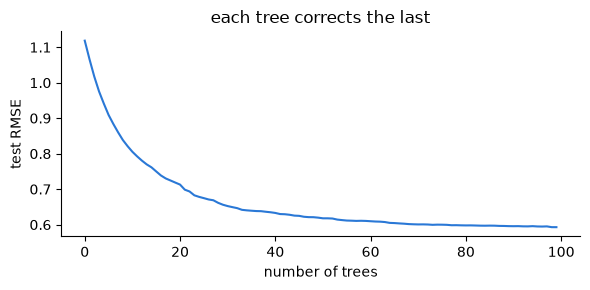

In [4]:
from sklearn.ensemble import GradientBoostingRegressor
import time

learning_rate, n_trees, tree_depth = 0.1, 100, 3

t0 = time.time()
prediction_train = np.full(len(y_train), y_train.mean())     # F_0: the constant
prediction_test = np.full(len(y_test), y_train.mean())
test_error_by_round = []
for m in range(n_trees):
    residuals = y_train - prediction_train                   # step 1: negative gradient of squared loss
    tree_m = RegressionTree(max_depth=tree_depth, min_rows_per_leaf=5).fit(X_train, residuals)   # step 2
    prediction_train += learning_rate * tree_m.predict(X_train)                                 # step 3
    prediction_test += learning_rate * tree_m.predict(X_test)
    test_error_by_round.append(rmse(y_test, prediction_test))
print(f"hand-rolled boosting: {n_trees} trees in {time.time() - t0:.0f}s, test RMSE {test_error_by_round[-1]:.4f}")

library_boost = GradientBoostingRegressor(n_estimators=n_trees, learning_rate=learning_rate, max_depth=tree_depth,
                                          min_samples_leaf=5, random_state=SEED).fit(X_train, y_train)
print(f"sklearn:              test RMSE {rmse(y_test, library_boost.predict(X_test)):.4f}")
print(f"one depth-3 tree:     test RMSE {rmse(y_test, hand_tree.predict(X_test)):.4f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(test_error_by_round, color=BLUE)
ax.set(xlabel="number of trees", ylabel="test RMSE", title="each tree corrects the last")
plt.tight_layout(); plt.show()

## 4. Random forest, for contrast

A forest is the other way to combine trees: grow many **deep** trees independently, each on a
bootstrap sample of rows and a random subset of features at each split, then average. No residuals,
no gradient. Averaging cancels the variance of individual overfit trees.

$$F_{\text{forest}}(x) = \frac{1}{B}\sum_{b=1}^{B} T_b(x)$$

Boosting reduces **bias** by sequentially correcting errors with shallow trees. Bagging reduces
**variance** by averaging deep ones. That is the whole bagging-versus-boosting distinction.

## Summary

- A tree chooses each split by scanning every feature and cutpoint for the largest error reduction. Greedy, no lookahead.
- Depth and minimum leaf size are the tree's only regularization.
- Gradient boosting fits each new tree to the negative gradient of the loss, which for squared error is the residual, and adds it scaled by $\eta$.
- A forest averages independent deep trees instead.

In [5]:
con.close()